In [49]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt


import pyccl as ccl
import sys
sys.path.append('../forecasts/')
import fisher_matrix_bao_SuEisenstein

import _tracer_spectroscopic_efficiency
import _survey_design_telescope_metrics
import _surveys
import _survey_design_science_metrics

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
import pickle
def save_pickle(dat, filename, **kwargs):
    file = open(filename,'wb')
    pickle.dump(dat, file)
    file.close()
def load(filename, **kwargs):
    with open(filename, 'rb') as fin:
        return pickle.load(fin, **kwargs)

In [51]:
path = './telescope_and_science_metrics/'

In [52]:
survey_design_bright = load(path + 'survey_design_Bright.pkl')
survey_design_grey = load(path + 'survey_design_Grey.pkl')
survey_design_dark = load(path + 'survey_design_Dark.pkl')

In [56]:
survey_design_bright['total_survey_Informations']

{'total_survey_time': array([0.42778919, 0.42778919, 0.42778919, 0.85557837, 0.85557837,
        0.85557837, 0.85557837, 0.85557837, 0.85557837]),
 'total_survey_efficiency': array([0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99, 0.99]),
 'total_survey_fisher_information_fnl': array([0.00025215, 0.00034981, 0.00044016, 0.00051076, 0.00055795,
        0.000591  , 0.00062676, 0.00066033, 0.00066033]),
 'total_survey_fisher_information_Da': array([ 8036.00227238, 12034.82507835, 17568.92981072, 23693.1523164 ,
        29021.53047669, 33168.90855023, 36349.60840833, 37993.75746142,
        37993.75746142]),
 'total_survey_fisher_information_H': array([2586.97691116, 3760.81087088, 5105.77976118, 6366.41276717,
        7330.53707336, 8025.04690973, 8579.47229745, 8927.02921746,
        8927.02921746])}

In [54]:
survey_design_bright[ 'per_tracer_forecasts'].keys()

dict_keys(['BG_bright_mag_max_eval', 'BG_bright_list_zbin_Da', 'BG_bright_zeff_Da', 'BG_bright_list_sigma_Da', 'BG_bright_sigma_Da_eff', 'BG_bright_list_zbin_H', 'BG_bright_zeff_H', 'BG_bright_list_sigma_H', 'BG_bright_sigma_H_eff', 'BG_bright_list_zbin_fnl', 'BG_bright_zeff_fnl', 'BG_bright_list_sigma_fnl', 'BG_bright_sigma_fnl_eff'])

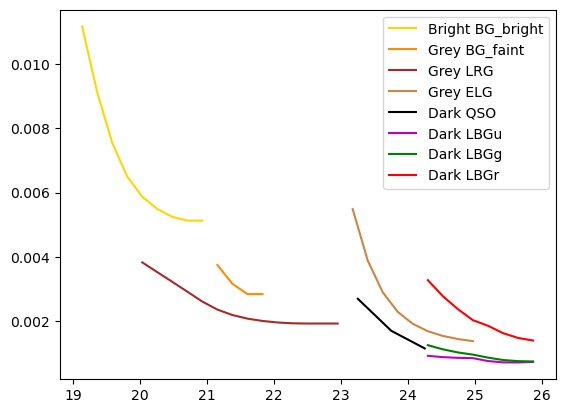

In [55]:
for survey in [survey_design_bright, survey_design_grey, survey_design_dark]:
    for i, tracer in enumerate(survey['config_survey']['tracers']):
        plt.plot(survey['config_survey'][tracer + '_mag_centers'], survey[ 'per_tracer_forecasts'][tracer + '_sigma_Da_eff'], 
                 color = survey['config_survey']['color'][i], label = survey['config_survey']['survey_type'] + ' ' + tracer)
plt.legend()

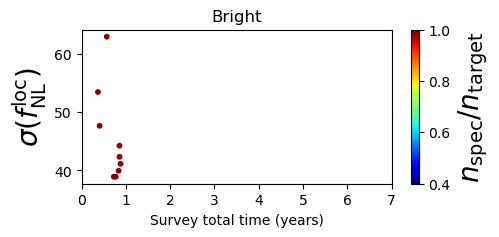

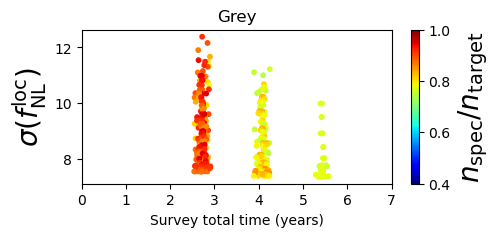

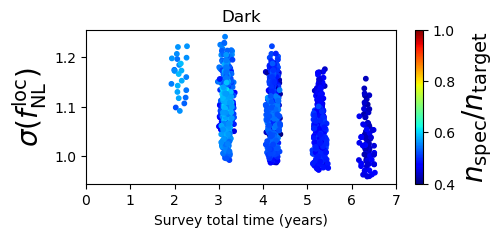

In [78]:
for survey in [survey_design_bright, survey_design_grey, survey_design_dark]:
    sigma_Da_target = 0.0006
    sigma_fnl_target = 1.1
    plt.figure(figsize=(5,2))
    Information_fnl = survey['total_survey_Informations']['total_survey_fisher_information_fnl']
    Information_Da = survey['total_survey_Informations']['total_survey_fisher_information_Da']
    total_time= survey['total_survey_Informations']['total_survey_time']
    total_survey_efficiency = survey['total_survey_Informations']['total_survey_efficiency']
    
    FoM_all = (sigma_fnl_target **2 * Information_fnl + sigma_Da_target **2 * Information_Da)
    FoM_fnl = sigma_fnl_target **2 * Information_fnl
    FoM_Da = sigma_Da_target **2 * Information_Da
    plt.title(survey['config_survey']['survey_type'])
    x = 2*np.random.random(len(total_time.flatten())) -1
    plt.scatter(total_time.flatten() + 0.2*x*np.linspace(-1, 1, len(total_time.flatten())), 
                1/Information_fnl**.5,
                c= total_survey_efficiency.flatten(), s=10, label = 'Combined', cmap='jet', vmax=1, vmin=0.4)
    plt.ylabel(r'$\sigma(f_{\rm NL}^{\rm loc})$', fontsize=20)
    plt.xlabel(r'Survey total time (years)', fontsize=10)
    cbar = plt.colorbar()
    cbar.set_label(r'$n_{\rm spec}/n_{\rm target}$', fontsize=20)
    plt.xlim(0, 7)